---
# PHẦN THỐNG KÊ — Data Collection & Statistical Computation

> **Chạy sau khi đã có `ALL_SYMBOLS` và `SECTOR_STOCKS` từ notebook chính.**

| Mục | Nội dung |
|-----|----------|
| Cell A | Cấu hình & tải giá tuần |
| Cell B | Risk-Free Rate (T-bill) |
| Cell C | Returns, Variance, Std Dev |
| Cell D | Ma trận Covariance & Correlation |

## Cell A1 — Danh sách mã cổ phiếu (Chỉnh tại đây)

In [1]:
START_DATE = '2025-06-01'
END_DATE   = '2025-12-31'

VN_INDEX_SYM = 'VNINDEX'

STATS_SECTOR_STOCKS = {
    'CP': ['GEE', 'NAF', 'LPB', 'HAH', 'FRT', 'CTS'],
}

STATS_ALL_SYMBOLS   = []
STATS_SYMBOL_SECTOR = {}
for sector, syms in STATS_SECTOR_STOCKS.items():
    for s in syms:
        STATS_ALL_SYMBOLS.append(s)
        STATS_SYMBOL_SECTOR[s] = sector

print(f'{START_DATE} -> {END_DATE}  |  {len(STATS_ALL_SYMBOLS)} ma co phieu + {VN_INDEX_SYM}')
for sector, syms in STATS_SECTOR_STOCKS.items():
    print(f'  {sector}: {", ".join(syms)}')



2025-06-01 -> 2025-12-31  |  6 ma co phieu + VNINDEX
  CP: GEE, NAF, LPB, HAH, FRT, CTS


## Cell A2 — Tải dữ liệu giá

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vnstock import Quote

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)

RESAMPLE_RULE = 'W-FRI'
DELAY_SEC     = 6
DATA_SOURCE   = 'vci'


def fetch_weekly_close(symbol, start, end):
    q  = Quote(source=DATA_SOURCE, symbol=symbol, random_agent=False, show_log=False)
    df = q.history(start=start, end=end, interval='1D')

    if df is None or df.empty:
        raise ValueError('empty response')

    df.columns = [c.lower().strip() for c in df.columns]

    time_col = next((c for c in ['time', 'date', 'tradingdate', 'datetime']
                     if c in df.columns), None)
    if time_col:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.set_index(time_col).sort_index()
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.sort_index()
    else:
        raise ValueError(f'no date column found: {list(df.columns)}')

    # adjusted close takes priority over raw close
    close_col = next((c for c in ['adjclose', 'adj_close', 'close', 'closeprice']
                      if c in df.columns), None)
    if close_col is None:
        raise ValueError(f'no close column: {list(df.columns)}')

    weekly = df[close_col].resample(RESAMPLE_RULE).last().dropna()
    if len(weekly) < 5:
        raise ValueError(f'only {len(weekly)} weeks')
    return weekly


price_dict  = {}
failed_syms = []

for i, sym in enumerate(STATS_ALL_SYMBOLS + [VN_INDEX_SYM], 1):
    label = 'INDEX' if sym == VN_INDEX_SYM else STATS_SYMBOL_SECTOR.get(sym, '')
    print(f'[{i:02d}] {sym:<8} {label:<20} ...', end=' ', flush=True)
    try:
        s = fetch_weekly_close(sym, START_DATE, END_DATE)
        time.sleep(DELAY_SEC)
        price_dict[sym] = s
        print(f'{len(s)} tuan, close = {s.iloc[-1]:,.0f}')
    except Exception as e:
        print(f'SKIP ({str(e)[:60]})')
        failed_syms.append(sym)

df_prices = pd.DataFrame(price_dict)
df_prices.index.name = 'week_end'
df_prices = df_prices.ffill(limit=1)

print(f'\n{len(price_dict)} / {len(STATS_ALL_SYMBOLS)+1} ma  |  {len(df_prices)} tuan')
if failed_syms:
    print(f'Loi: {failed_syms}')

nan_warn = (df_prices.isna().mean() * 100).pipe(lambda s: s[s > 10])
if not nan_warn.empty:
    print('Thieu >10% du lieu:')
    for sym, pct in nan_warn.items():
        print(f'  {sym}: {pct:.1f}%')

from IPython.display import display
display(df_prices.tail().style.format('{:,.0f}'))



[01] GEE      CP                   ... 32 tuan, close = 246
[02] NAF      CP                   ... 32 tuan, close = 38
[03] LPB      CP                   ... 32 tuan, close = 42
[04] HAH      CP                   ... 32 tuan, close = 59
[05] FRT      CP                   ... 32 tuan, close = 150
[06] CTS      CP                   ... 32 tuan, close = 33
[07] VNINDEX  INDEX                ... 32 tuan, close = 1,784

7 / 7 ma  |  32 tuan


,GEE,NAF,LPB,HAH,FRT,CTS,VNINDEX
week_end,,,,,,,
2025-12-05 00:00:00,227,33,48,60,160,35,"1,741"
2025-12-12 00:00:00,180,34,44,56,140,33,"1,647"
2025-12-19 00:00:00,184,36,44,58,144,34,"1,704"
2025-12-26 00:00:00,216,36,42,60,144,34,"1,730"
2026-01-02 00:00:00,246,38,42,59,150,33,"1,784"


## Cell B — Treasury Bill (Risk-Free Rate)

In [3]:
# https://vn.investing.com/rates-bonds/vietnam-1-year-bond-yield
TBILL_RATES_ANNUAL = {
    '2025-06-06': 0.02281, '2025-06-13': 0.02279, '2025-06-20': 0.02316,
    '2025-06-27': 0.02319, '2025-07-04': 0.02327, '2025-07-11': 0.02409,
    '2025-07-18': 0.02413, '2025-07-25': 0.02458, '2025-08-01': 0.02489,
    '2025-08-08': 0.02547, '2025-08-15': 0.02634, '2025-08-22': 0.02687,
    '2025-08-29': 0.02782, '2025-09-05': 0.02799, '2025-09-12': 0.02811,
    '2025-09-19': 0.02819, '2025-09-26': 0.02838, '2025-10-03': 0.02854,
    '2025-10-10': 0.02872, '2025-10-17': 0.02892, '2025-10-24': 0.02933,
    '2025-10-31': 0.02933, '2025-11-07': 0.02938, '2025-11-14': 0.02983,
    '2025-11-21': 0.03004, '2025-11-28': 0.03004, '2025-12-05': 0.03047,
    '2025-12-12': 0.03059, '2025-12-19': 0.03071, '2025-12-26': 0.03066,
    '2026-01-02': 0.03069,
}

tbill_annual = pd.Series(TBILL_RATES_ANNUAL, dtype=float)
tbill_annual.index = pd.to_datetime(tbill_annual.index)
tbill_annual.index.name = 'week_end'

# geometric compounding: rf_weekly = (1 + rf_annual)^(1/52) - 1
tbill_weekly  = (1 + tbill_annual) ** (1 / 52) - 1
tbill_aligned = tbill_weekly.reindex(df_prices.index).ffill(limit=2)

RF_WEEKLY_AVG = float(tbill_aligned.mean())
RF_ANNUAL_AVG = (1 + RF_WEEKLY_AVG) ** 52 - 1

print(f'Rf tuan (geo): {RF_WEEKLY_AVG*100:.6f}%')
print(f'Rf nam  (geo): {RF_ANNUAL_AVG*100:.4f}%')
print(f'Khop voi ky phan tich: {tbill_aligned.notna().sum()} tuan')

df_tbill_display = pd.DataFrame({
    'Annual (%)':    tbill_annual.reindex(df_prices.index).ffill(limit=2) * 100,
    'Weekly_Geo (%)':    tbill_aligned * 100,
    'Annual_Verify (%)': ((1 + tbill_aligned) ** 52 - 1) * 100,
}).dropna()

from IPython.display import display
display(df_tbill_display.round(6))



Rf tuan (geo): 0.051986%
Rf nam  (geo): 2.7394%
Khop voi ky phan tich: 31 tuan


,Annual (%),Weekly_Geo (%),Annual_Verify (%)
week_end,,,
2025-06-06,2.281000,0.043382,2.281000
2025-06-13,2.279000,0.043344,2.279000
2025-06-20,2.316000,0.044040,2.316000
2025-06-27,2.319000,0.044097,2.319000
2025-07-04,2.327000,0.044247,2.327000
2025-07-11,2.409000,0.045788,2.409000
2025-07-18,2.413000,0.045863,2.413000
2025-07-25,2.458000,0.046709,2.458000
2025-08-01,2.489000,0.047291,2.489000


## Cell C — Returns, Variance, Standard Deviation

In [4]:
df_returns     = df_prices.pct_change()
df_log_returns = np.log(df_prices / df_prices.shift(1))

df_returns_clean     = df_returns.dropna(how='all')
df_log_returns_clean = df_log_returns.dropna(how='all')

expected_returns = df_returns_clean.mean()
variances        = df_returns_clean.var(ddof=1)
std_devs         = df_returns_clean.std(ddof=1)
sharpe_weekly    = (expected_returns - RF_WEEKLY_AVG) / std_devs

# Ghi chu: KHONG annualize — window 7 thang qua ngan,
# (1+r_weekly)^52 - 1 cho so khong co y nghia kinh te voi window ngan.
# Tat ca chi so giu nguyen don vi TUAN.

df_stats = pd.DataFrame({
    'E[r] weekly' : expected_returns,
    'Var weekly'  : variances,
    'Std weekly'  : std_devs,
    'Sharpe'      : sharpe_weekly,
    'Log E[r]'    : df_log_returns_clean.mean(),
    'Log Std'     : df_log_returns_clean.std(ddof=1),
    'n_obs'       : df_returns_clean.count(),
})
df_stats['Loai'] = df_stats.index.map(
    lambda s: 'INDEX' if s == VN_INDEX_SYM else STATS_SYMBOL_SECTOR.get(s, 'Co phieu')
)
df_stats = df_stats.sort_values(['Loai', 'Sharpe'], ascending=[True, False])

n_dropped = len(df_returns) - len(df_returns_clean)
print(f'{len(df_returns_clean)} tuan  ({n_dropped} bo do all-NaN)')
print(f'Rf: {RF_WEEKLY_AVG*100:.6f}%/tuan  (tuong duong {RF_ANNUAL_AVG*100:.4f}%/nam — chi de tham khao)')

nan_per_col = df_returns_clean.isna().sum()
for sym, cnt in nan_per_col[nan_per_col > 0].items():
    print(f'  {sym}: con {cnt} tuan NaN, tinh tu {len(df_returns_clean)-cnt} quan sat')

from IPython.display import display

disp = df_stats[['Loai', 'n_obs', 'E[r] weekly', 'Std weekly', 'Sharpe']].copy()
disp['E[r] weekly'] = disp['E[r] weekly'].apply(lambda x: f'{x*100:.4f}%')
disp['Std weekly']  = disp['Std weekly'].apply(lambda x: f'{x*100:.4f}%')
disp['Sharpe']      = disp['Sharpe'].apply(lambda x: f'{x:.4f}')
display(disp)

# Top Sharpe (khong gom index)
stocks_only = df_stats[df_stats.index != VN_INDEX_SYM].sort_values('Sharpe', ascending=False)
print('\nXep hang Sharpe weekly (tuan):')
for sym, row in stocks_only.iterrows():
    print(f'  {sym:<6}  E[r]={row["E[r] weekly"]*100:.4f}%  '
          f'Std={row["Std weekly"]*100:.4f}%  Sharpe={row["Sharpe"]:.4f}  n={int(row["n_obs"])}')

mkt = df_stats.loc[VN_INDEX_SYM]
print(f'\nVNINDEX  E[r]={mkt["E[r] weekly"]*100:.4f}%/tuan'
      f'  Std={mkt["Std weekly"]*100:.4f}%/tuan'
      f'  Sharpe={mkt["Sharpe"]:.4f}'
      f'  n={int(mkt["n_obs"])}')


31 tuan  (1 bo do all-NaN)
Rf: 0.051986%/tuan  (tuong duong 2.7394%/nam — chi de tham khao)


,Loai,n_obs,E[r] weekly,Std weekly,Sharpe
NAF,CP,31,2.1356%,5.3473%,0.3897
GEE,CP,31,3.6297%,10.8739%,0.3290
LPB,CP,31,1.0157%,5.3392%,0.1805
CTS,CP,31,1.1116%,7.7722%,0.1363
FRT,CP,31,0.4891%,5.5101%,0.0793
HAH,CP,31,0.0706%,4.5005%,0.0041
VNINDEX,INDEX,31,0.9803%,2.6551%,0.3496



Xep hang Sharpe weekly (tuan):
  NAF     E[r]=2.1356%  Std=5.3473%  Sharpe=0.3897  n=31
  GEE     E[r]=3.6297%  Std=10.8739%  Sharpe=0.3290  n=31
  LPB     E[r]=1.0157%  Std=5.3392%  Sharpe=0.1805  n=31
  CTS     E[r]=1.1116%  Std=7.7722%  Sharpe=0.1363  n=31
  FRT     E[r]=0.4891%  Std=5.5101%  Sharpe=0.0793  n=31
  HAH     E[r]=0.0706%  Std=4.5005%  Sharpe=0.0041  n=31

VNINDEX  E[r]=0.9803%/tuan  Std=2.6551%/tuan  Sharpe=0.3496  n=31


## Cell D — Ma trận Covariance & Correlation

Ma tran 7 x 7  |  min_periods=10
  diagonal corr = 1 : ok
  cov PSD            : ok
  cov symmetric      : ok

Covariance (x10^4):


,VNINDEX,GEE,NAF,LPB,HAH,FRT,CTS
VNINDEX,7.049700,12.545400,-3.277500,2.259400,0.302200,6.848200,10.170700
GEE,12.545400,118.241600,-15.476100,4.774400,7.784100,27.858600,15.066200
NAF,-3.277500,-15.476100,28.594000,-1.853100,2.836700,-5.631000,-4.854400
LPB,2.259400,4.774400,-1.853100,28.506800,-3.777700,-3.771600,-5.064900
HAH,0.302200,7.784100,2.836700,-3.777700,20.254500,6.951600,11.201900
FRT,6.848200,27.858600,-5.631000,-3.771600,6.951600,30.361100,12.781100
CTS,10.170700,15.066200,-4.854400,-5.064900,11.201900,12.781100,60.406600



Correlation:


,VNINDEX,GEE,NAF,LPB,HAH,FRT,CTS
VNINDEX,1.000000,0.434500,-0.230800,0.159400,0.025300,0.468100,0.492900
GEE,0.434500,1.000000,-0.266200,0.082200,0.159100,0.465000,0.178300
NAF,-0.230800,-0.266200,1.000000,-0.064900,0.117900,-0.191100,-0.116800
LPB,0.159400,0.082200,-0.064900,1.000000,-0.157200,-0.128200,-0.122100
HAH,0.025300,0.159100,0.117900,-0.157200,1.000000,0.280300,0.320300
FRT,0.468100,0.465000,-0.191100,-0.128200,0.280300,1.000000,0.298400
CTS,0.492900,0.178300,-0.116800,-0.122100,0.320300,0.298400,1.000000


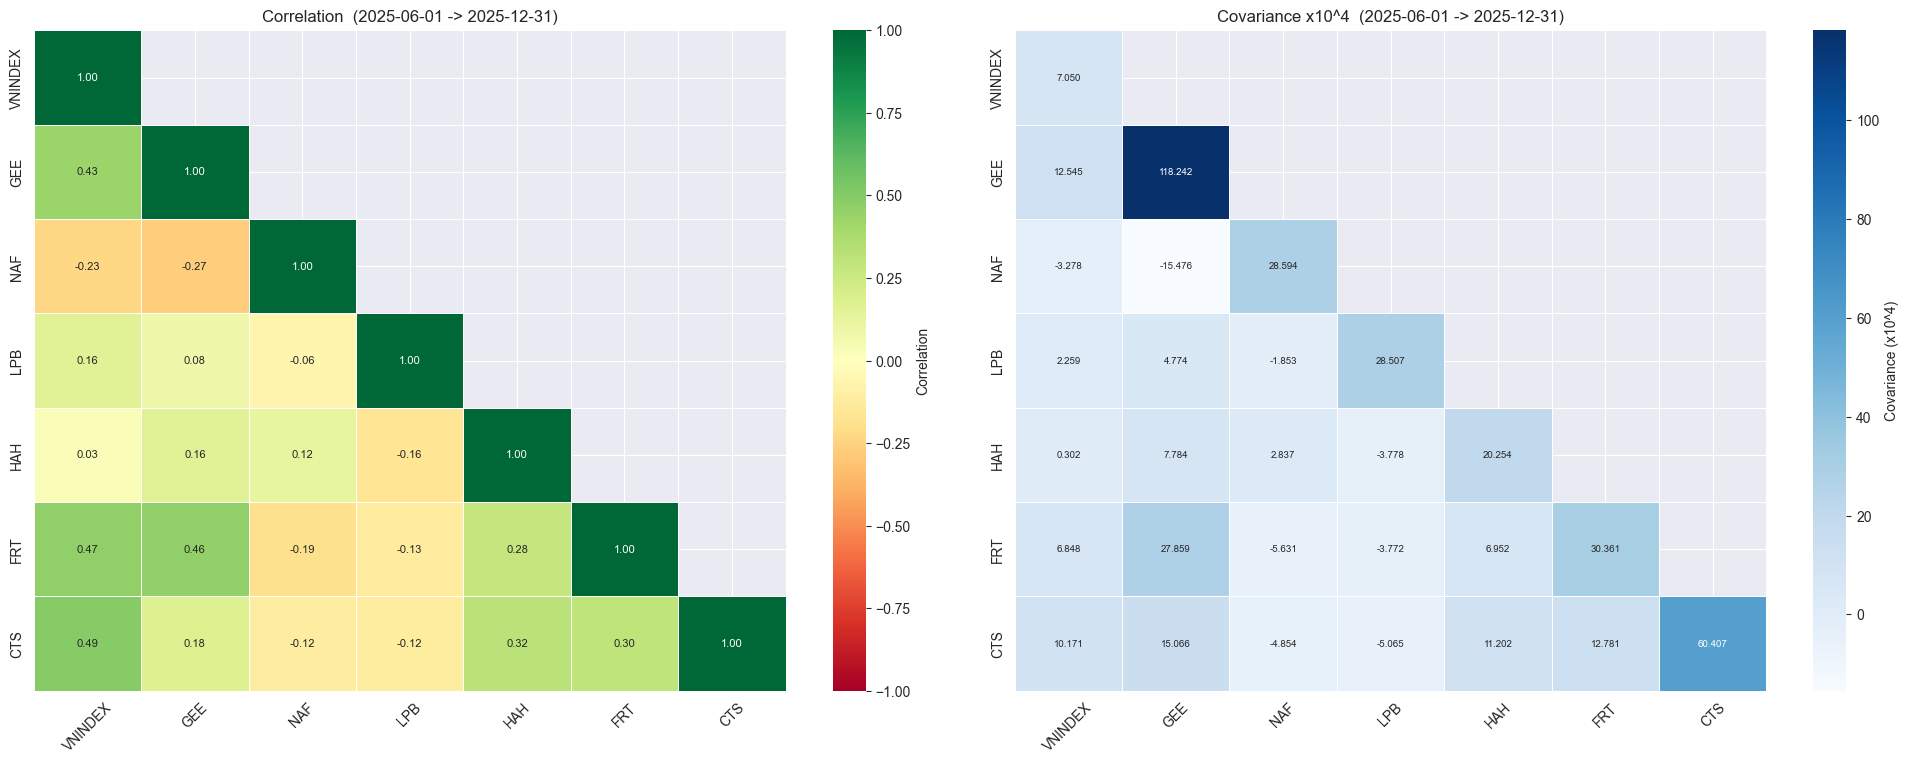

In [5]:
stock_cols = [s for s in df_returns_clean.columns
              if s != VN_INDEX_SYM and s in STATS_ALL_SYMBOLS]
col_order   = [VN_INDEX_SYM] + stock_cols
col_order   = [c for c in col_order if c in df_returns_clean.columns]
df_ret_ord  = df_returns_clean[col_order]

MIN_PERIODS = 10
cov_matrix  = df_ret_ord.cov(min_periods=MIN_PERIODS)
corr_matrix = df_ret_ord.corr(method='pearson', min_periods=MIN_PERIODS)

# Kiem tra tinh hop le
diag_ok  = np.allclose(np.diag(corr_matrix.values), 1.0, atol=1e-10)
eigvals  = np.linalg.eigvalsh(np.nan_to_num(cov_matrix.values))
is_psd   = bool(np.all(eigvals >= -1e-10))
is_sym   = np.allclose(np.nan_to_num(cov_matrix.values),
                        np.nan_to_num(cov_matrix.values.T), atol=1e-10)

print(f'Ma tran {len(col_order)} x {len(col_order)}  |  min_periods={MIN_PERIODS}')
print(f'  diagonal corr = 1 : {"ok" if diag_ok else "FAIL"}')
print(f'  cov PSD            : {"ok" if is_psd  else "FAIL  (eigenvalue min = " + f"{eigvals.min():.2e})"}')
print(f'  cov symmetric      : {"ok" if is_sym  else "FAIL"}')

nan_count = corr_matrix.isna().sum().sum()
if nan_count:
    print(f'  {nan_count} phan tu NaN (overlap < {MIN_PERIODS} tuan)')

if not is_psd:
    print('\n  Cov khong PSD: thu bo ma co it overlap, tang MIN_PERIODS,')
    print('  hoac dung Ledoit-Wolf shrinkage (sklearn.covariance).')

from IPython.display import display
print('\nCovariance (x10^4):')
display((cov_matrix * 1e4).round(4))
print('\nCorrelation:')
display(corr_matrix.round(4))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'label': 'Correlation'})
axes[0].set_title(f'Correlation  ({START_DATE} -> {END_DATE})', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cov_matrix * 1e4, mask=mask, ax=axes[1],
            annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'label': 'Covariance (x10^4)'})
axes[1].set_title(f'Covariance x10^4  ({START_DATE} -> {END_DATE})', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(pad=2)
plt.savefig('corr_cov_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



## Cell E — Tổng hợp & Xuất Excel

In [6]:
OUTPUT_STATS = 'vn_stock_stats.xlsx'

with pd.ExcelWriter(OUTPUT_STATS, engine='openpyxl') as writer:
    df_prices.to_excel(writer,            sheet_name='Weekly Prices')
    df_returns_clean.to_excel(writer,     sheet_name='Weekly Returns')
    df_log_returns_clean.to_excel(writer, sheet_name='Log Returns')
    # chi giu weekly stats, bo annual
    df_stats.drop(columns=['Loai', 'Log E[r]', 'Log Std'], errors='ignore') \
            .to_excel(writer, sheet_name='Descriptive Stats')
    cov_matrix.to_excel(writer,           sheet_name='Covariance Matrix')
    corr_matrix.to_excel(writer,          sheet_name='Correlation Matrix')
    df_tbill_display.to_excel(writer,     sheet_name='TBill Rates')

    pd.DataFrame({
        'Chi so': [
            'Ky phan tich', 'So tuan', 'So ma', 'Nguon gia',
            'Nguon T-bill', 'Rf tuan (geo)', 'Rf nam (tham khao)',
            'Don vi stats', 'dropna', 'min_periods',
        ],
        'Gia tri': [
            f'{START_DATE} -> {END_DATE}',
            str(len(df_returns_clean)),
            str(len(col_order)),
            DATA_SOURCE.upper(),
            'HNX dau thau TPCP 364 ngay',
            f'{RF_WEEKLY_AVG*100:.6f}%',
            f'{RF_ANNUAL_AVG*100:.4f}% (chi tham khao, khong dung de tinh)',
            'TUAN — khong annualize vi window < 1 nam',
            'how=all',
            str(MIN_PERIODS),
        ]
    }).to_excel(writer, sheet_name='Summary', index=False)

    for sheet in writer.sheets.values():
        for col_cells in sheet.columns:
            max_len = max((len(str(c.value or '')) for c in col_cells[:50]), default=10)
            sheet.column_dimensions[col_cells[0].column_letter].width = min(max_len + 2, 30)

print(f'Da luu: {OUTPUT_STATS}')


Da luu: vn_stock_stats.xlsx


## Cell F — Xuất OHLCV Daily (Long Format — khớp cấu trúc file mẫu)

In [7]:
OUTPUT_OHLCV = 'vn_stock_ohlcv_daily.xlsx'


def fetch_daily_ohlcv(symbol, start, end):
    q  = Quote(source=DATA_SOURCE, symbol=symbol, random_agent=False, show_log=False)
    df = q.history(start=start, end=end, interval='1D')

    if df is None or df.empty:
        raise ValueError('empty response')

    df.columns = [c.lower().strip() for c in df.columns]

    time_col = next((c for c in ['time', 'date', 'tradingdate', 'datetime']
                     if c in df.columns), None)
    if time_col:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.rename(columns={time_col: 'date'})
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index().rename(columns={df.index.name or 'index': 'date'})
    else:
        raise ValueError(f'no date column: {list(df.columns)}')

    df = df.sort_values('date').reset_index(drop=True)
    df = df.rename(columns={
        'adj_close': 'close', 'adjclose': 'close', 'closeprice': 'close',
        'openprice': 'open',  'highprice': 'high', 'lowprice': 'low',
        'tradingvolume': 'volume', 'vol': 'volume',
    })

    keep = [c for c in ['date', 'open', 'high', 'low', 'close', 'volume']
            if c in df.columns]
    df = df[keep].copy()

    for c in ['open', 'high', 'low', 'close']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').round(2)
    if 'volume' in df.columns:
        df['volume'] = pd.to_numeric(df['volume'], errors='coerce').astype('Int64')

    df['ticker'] = symbol
    return df


ohlcv_frames = []
failed_ohlcv = []

for i, sym in enumerate(STATS_ALL_SYMBOLS + [VN_INDEX_SYM], 1):
    label = 'INDEX' if sym == VN_INDEX_SYM else STATS_SYMBOL_SECTOR.get(sym, '')
    print(f'[{i:02d}] {sym:<8} {label:<20} ...', end=' ', flush=True)
    try:
        df_sym = fetch_daily_ohlcv(sym, START_DATE, END_DATE)
        time.sleep(DELAY_SEC)
        ohlcv_frames.append(df_sym)
        print(f'{len(df_sym)} ngay, close = {df_sym["close"].iloc[-1]:,.2f}')
    except Exception as e:
        print(f'SKIP ({str(e)[:60]})')
        failed_ohlcv.append(sym)

if not ohlcv_frames:
    print('Khong co du lieu nao tai duoc.')
else:
    df_ohlcv = (pd.concat(ohlcv_frames, ignore_index=True)
                .sort_values(['ticker', 'date'])
                .reset_index(drop=True))
    df_ohlcv.columns = [c.capitalize() for c in df_ohlcv.columns]
    df_ohlcv['Date'] = pd.to_datetime(df_ohlcv['Date']).dt.strftime('%Y-%m-%d')

    with pd.ExcelWriter(OUTPUT_OHLCV, engine='openpyxl') as writer:
        df_ohlcv.to_excel(writer, sheet_name='Sheet1', index=False)
        ws = writer.sheets['Sheet1']
        for col_cells in ws.columns:
            max_len = max((len(str(c.value or '')) for c in col_cells), default=10)
            ws.column_dimensions[col_cells[0].column_letter].width = min(max_len + 3, 25)

    from IPython.display import display
    print(f'\n{len(ohlcv_frames)} / {len(STATS_ALL_SYMBOLS)+1} ma  |  {len(df_ohlcv):,} dong')
    if failed_ohlcv:
        print(f'Loi: {failed_ohlcv}')

    display(df_ohlcv.head(10))
    display(df_ohlcv.groupby('Ticker')['Date'].agg(['first', 'last', 'count']))
    print(f'\nDa luu: {OUTPUT_OHLCV}')



[01] GEE      CP                   ... 155 ngay, close = 245.50
[02] NAF      CP                   ... 155 ngay, close = 37.95
[03] LPB      CP                   ... 155 ngay, close = 41.80
[04] HAH      CP                   ... 155 ngay, close = 58.70
[05] FRT      CP                   ... 155 ngay, close = 149.50
[06] CTS      CP                   ... 155 ngay, close = 33.15
[07] VNINDEX  INDEX                ... 155 ngay, close = 1,784.49

7 / 7 ma  |  1,085 dong


,Date,Open,High,Low,Close,Volume,Ticker
0,2025-05-27,24.480000,24.690000,24.200000,24.620000,1810340,CTS
1,2025-05-28,25.170000,25.170000,24.480000,24.580000,1756367,CTS
2,2025-05-29,24.830000,25.000000,24.480000,24.550000,1375682,CTS
3,2025-05-30,24.690000,26.150000,24.580000,25.560000,4342612,CTS
4,2025-06-02,25.870000,26.780000,25.660000,26.710000,2916937,CTS
5,2025-06-03,27.060000,27.270000,26.540000,26.610000,4514480,CTS
6,2025-06-04,26.710000,26.710000,26.120000,26.220000,3118100,CTS
7,2025-06-05,27.200000,27.200000,26.500000,26.550000,2900391,CTS
8,2025-06-06,26.700000,26.700000,25.600000,25.750000,2198260,CTS
9,2025-06-09,25.750000,26.150000,25.500000,25.800000,1007261,CTS


,first,last,count
Ticker,,,
CTS,2025-05-27,2025-12-31,155
FRT,2025-05-27,2025-12-31,155
GEE,2025-05-27,2025-12-31,155
HAH,2025-05-27,2025-12-31,155
LPB,2025-05-27,2025-12-31,155
NAF,2025-05-27,2025-12-31,155
VNINDEX,2025-05-27,2025-12-31,155



Da luu: vn_stock_ohlcv_daily.xlsx
